### Load Packages

In [2]:
using LinearAlgebra
using JuMP, MosekTools, ECOS
using Printf
using PyPlot
using Colors

### Include files

In [3]:
core_path = "../../src/core/"
module_path = "../../src/quad3dofcage/"

# Include base core files
include(core_path * "globals.jl")
include(core_path * "structs.jl")

# Include module files
include(module_path * "params.jl")
include(module_path * "scenarios.jl")
include(module_path * "prob_opt.jl")
include(module_path * "prob_scp.jl")
include(module_path * "prob_ddto.jl")
include(module_path * "prob_ddtoscp.jl")
include(module_path * "dynamics.jl")
include(module_path * "initial_guess.jl")

# Include utility files (dependent on module file definitions)
include(core_path * "disc.jl")
include(core_path * "sim.jl")
include(core_path * "utils_ddto.jl")
include(core_path * "utils_ddtoscp.jl")
;

### Solve

In [4]:
# ..:: Setup ::..
params = Params()
scenario_toy1!(params)

# Augment boundary states if using free-final-time (do not want affine form)
if params.free_final_time
    params.z0 = vcat(params.z0, 1)
    params.zf_targs = vcat(params.zf_targs, ones(1,params.n_targs))
end

# ..:: Execute solver sequence ::..
@time begin
    @time begin
        # ..:: Solve for independently-optimal solutions to each target ::..
        scp_solutions = solve_decoupled_scp_tree(params)
        scp_costs = CVector(zeros(params.n_targs))
        for k = 1:params.n_targs
            scp_costs[k] = scp_solutions[k].cost
        end
        println("\n Solve time for generating optimal solutions to each target:")
    end

    @time begin
        # ..:: Solve for DDTO branching solutions to ALL targets ::..
        (feas_ddtoscp, ddtoscp_solutions) = solve_ddtoscp_tree(deepcopy(params), scp_costs, deepcopy(scp_solutions))
        println("\n Solve time for generating DDTO branch solutions to all targets:")
    end
    println("\n Solve time for the full DDTO solution stack:")
end
;


=== Decoupled SCP solutions for each target ===
Target: 1
   SCP Iter:  1 | Status: Feasible | μ_ctrl_pen = 4.92e-12 | μ_obs_pen = 1.18e-09 | η_pen = 3.45e+01
   SCP Iter:  2 | Status: Feasible | μ_ctrl_pen = 9.22e-13 | μ_obs_pen = 9.10e-11 | η_pen = 9.96e+00
   SCP Iter:  3 | Status: Feasible | μ_ctrl_pen = 1.79e-12 | μ_obs_pen = 1.64e-10 | η_pen = 4.29e+00
   SCP Iter:  4 | Status: Feasible | μ_ctrl_pen = 1.53e-14 | μ_obs_pen = 1.12e-12 | η_pen = 5.70e-01
   SCP Iter:  5 | Status: Feasible | μ_ctrl_pen = 5.76e-15 | μ_obs_pen = 6.38e-14 | η_pen = 4.73e-02
   SCP Iter:  6 | Status: Feasible | μ_ctrl_pen = 2.58e-14 | μ_obs_pen = 1.44e-11 | η_pen = 4.79e-03
   > Convergence condition has been reached, exiting subproblem iteration.
   > Total cost: 78.872

Target: 2
   SCP Iter:  1 | Status: Feasible | μ_ctrl_pen = 4.61e-12 | μ_obs_pen = 9.46e-10 | η_pen = 3.45e+01
   SCP Iter:  2 | Status: Feasible | μ_ctrl_pen = 7.84e-13 | μ_obs_pen = 1.47e-10 | η_pen = 1.06e+01
   SCP Iter:  3 | Statu

### Simulate & Post-Process

In [5]:
# Convert DDTO solutions to branch solutions
ddtoscp_bsolutions, defer_bsolutions = extract_target_trajectories(params, ddtoscp_solutions)

# Port decoupled SCP solutions to `BranchSolution` objects for type conformance
scp_bsolutions_ = Vector{BranchSolution}(undef,params.n_targs)
for j=1:params.n_targs
    scp_bsolutions_[j] = BranchSolution(scp_solutions[j],-1,-1)
end
scp_bsolutions = scp_bsolutions_

# ..:: Simulate each target solution from I.C. to T.C.
@time begin
    if params.free_final_time
        dynamics = (t,x,sol) -> dyn_nl(t,x,optimal_controller(t,sol.t,sol.u,params.disc),params)
    else
        dynamics = (t,x,sol) -> params.A_c*x + params.B_c*optimal_controller(t,sol.t,sol.u,params.disc) + params.p_c
    end
    scp_bsimulations = simulate_branches(scp_bsolutions, dynamics, params.disc)
    ddtoscp_bsimulations = simulate_branches(ddtoscp_bsolutions, dynamics, params.disc)
    defer_bsimulations = simulate_branches(defer_bsolutions, dynamics, params.disc)
    println("\n Solve time for RK4 simulation:")
end

# ..:: Post-processing ::..
@time begin
    scp_solutions_proc       = process_solutions(scp_bsolutions, params)
    scp_simulations_proc     = process_solutions(scp_bsimulations, params)
    ddtoscp_solutions_proc   = process_solutions(ddtoscp_bsolutions, params)
    ddtoscp_simulations_proc = process_solutions(ddtoscp_bsimulations, params)
    defer_solutions_proc     = process_solutions(defer_bsolutions, params)
    defer_simulations_proc   = process_solutions(defer_bsimulations, params)
    println("\n Solve time for post-processing:")
end

# Deferrable segment solution/simulation should just be a scalar ProcessedSolution
defer_bsolutions = defer_bsolutions[1].sol
defer_bsimulations = defer_bsimulations[1].sol
defer_solutions_proc = defer_solutions_proc[1].sol
defer_simulations_proc = defer_simulations_proc[1].sol
;


 Solve time for RK4 simulation:
  0.644070 seconds (1.77 M allocations: 156.214 MiB, 5.59% gc time, 72.15% compilation time)

 Solve time for post-processing:
  0.002205 seconds (21.56 k allocations: 2.508 MiB)


### Plots

In [6]:
include(module_path * "plots.jl")
set_fonts()
set_fonts()
PyPlot.close("all")
pygui(false)
;

#### Decoupled SCP Plots

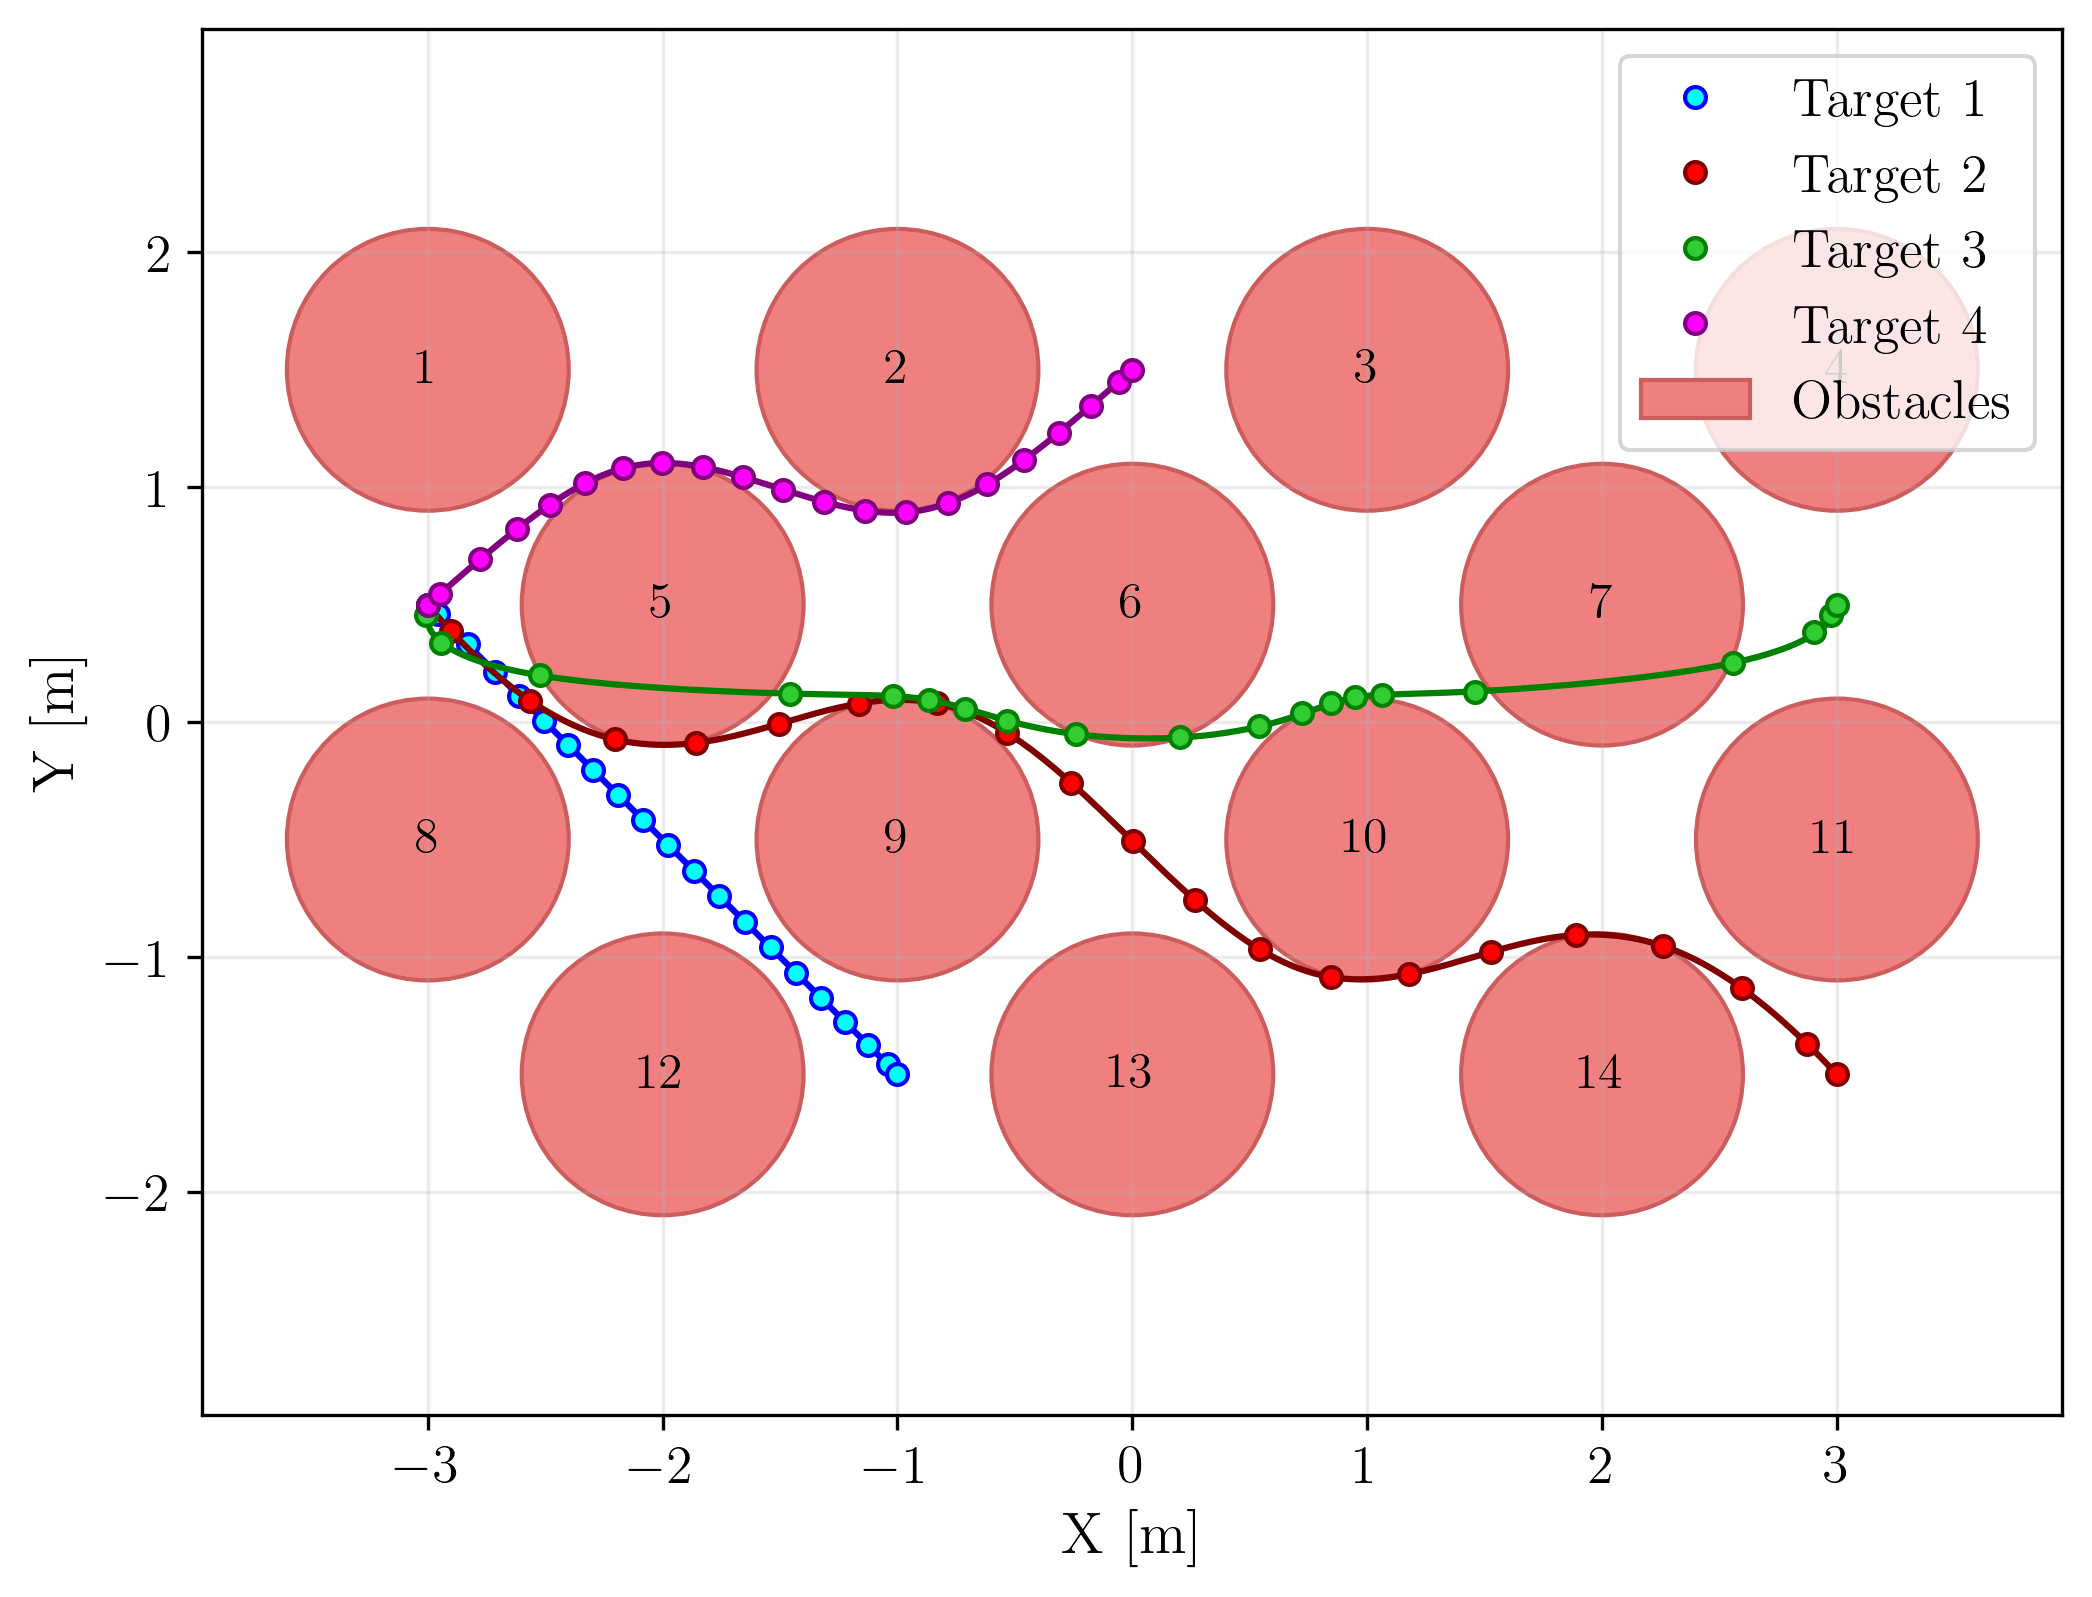

In [7]:
plot_parametric_trajectories(
    params,
    scp_solutions_proc,
    scp_simulations_proc;
    display_obstacles=true, 
    fname="decoupled_scp_solutions")

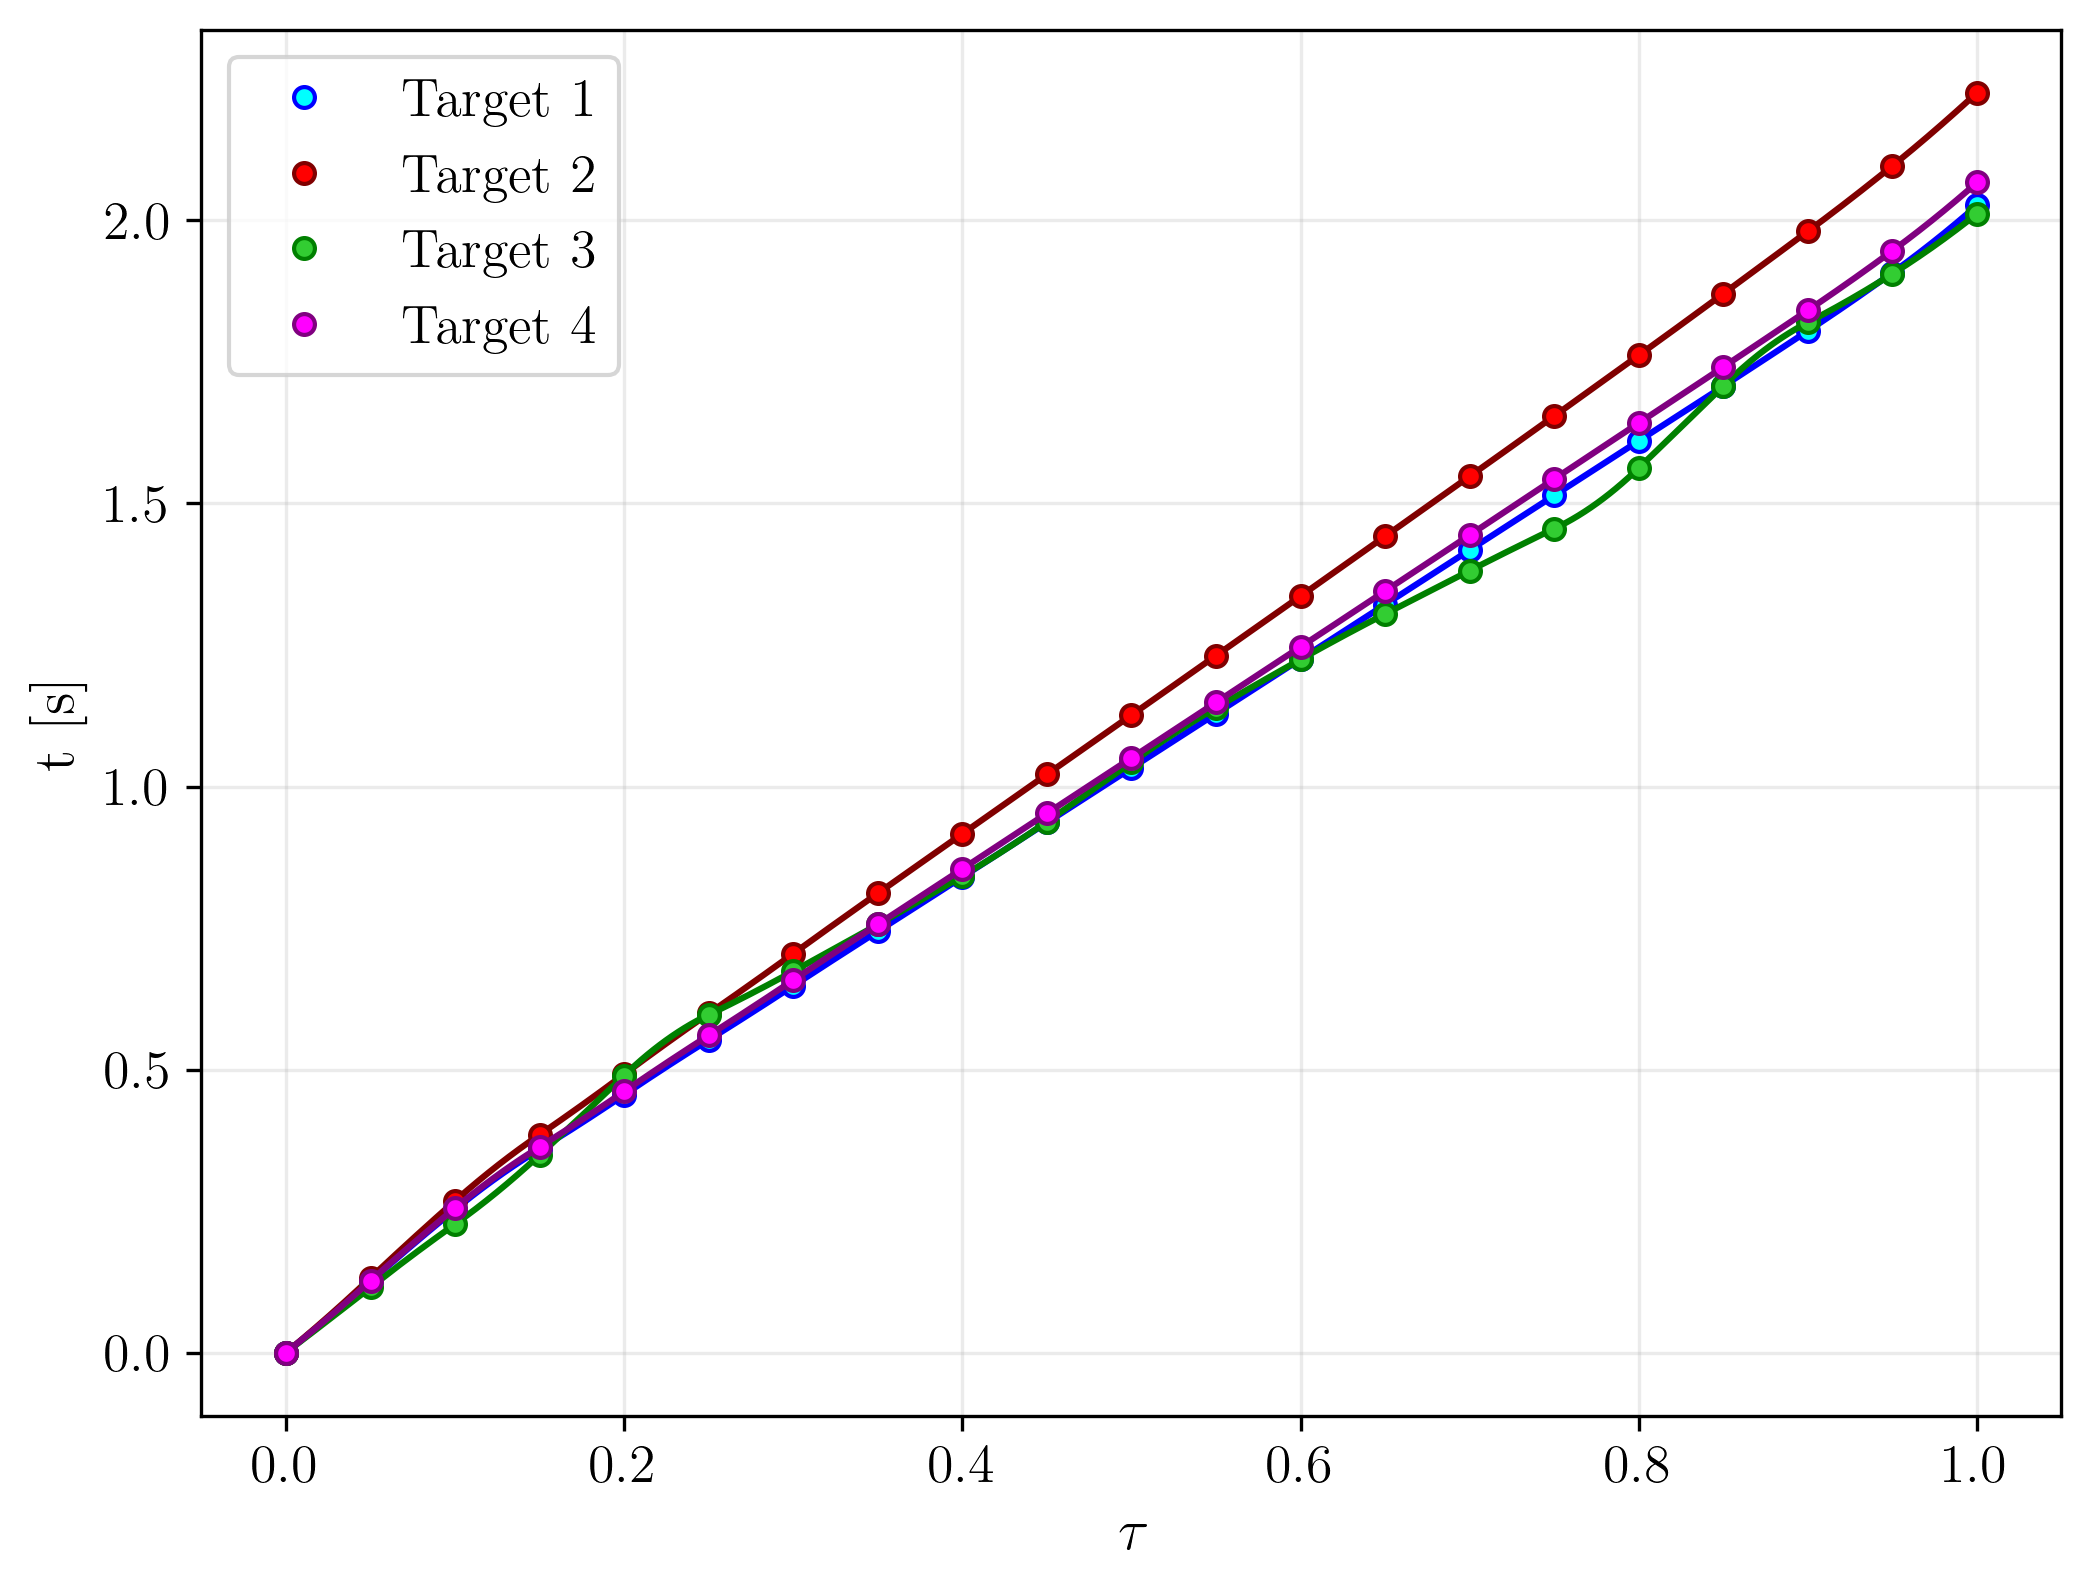

In [8]:
if params.free_final_time
    plot_time_dilation(
        params, 
        scp_solutions_proc, 
        scp_simulations_proc;
        fname="plot_time_dilation")
end

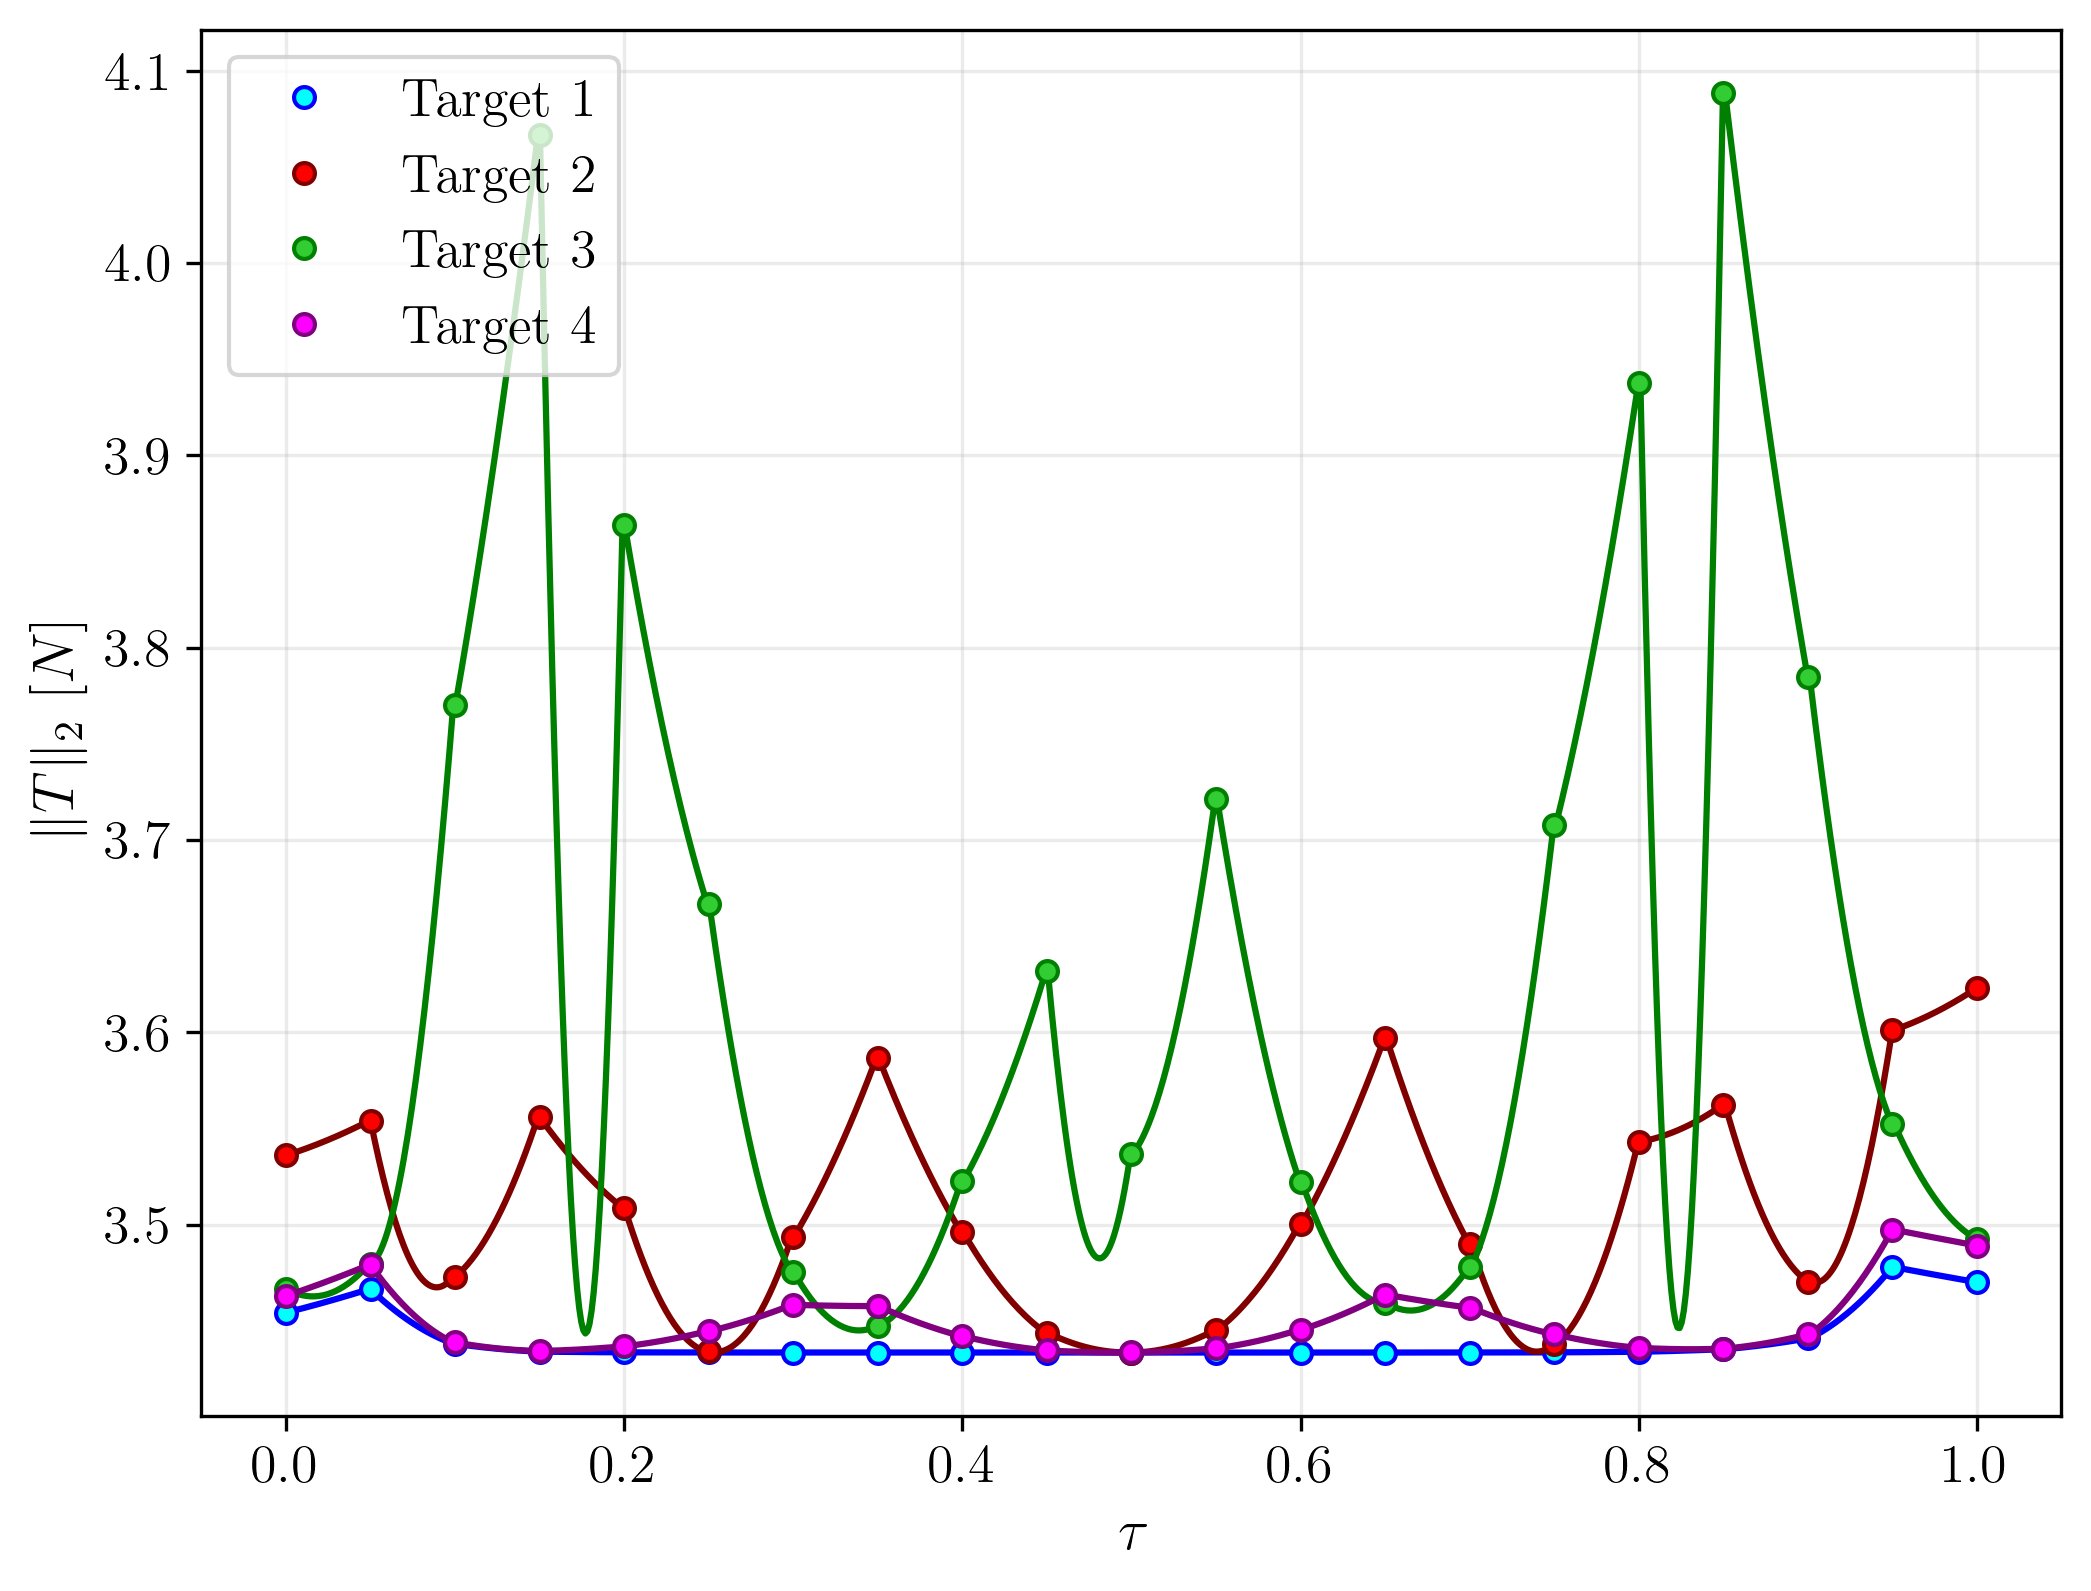

In [9]:
plot_thrust_magnitude(
    params, 
    scp_solutions_proc, 
    scp_simulations_proc;
    fname="plot_thrust_magnitude")

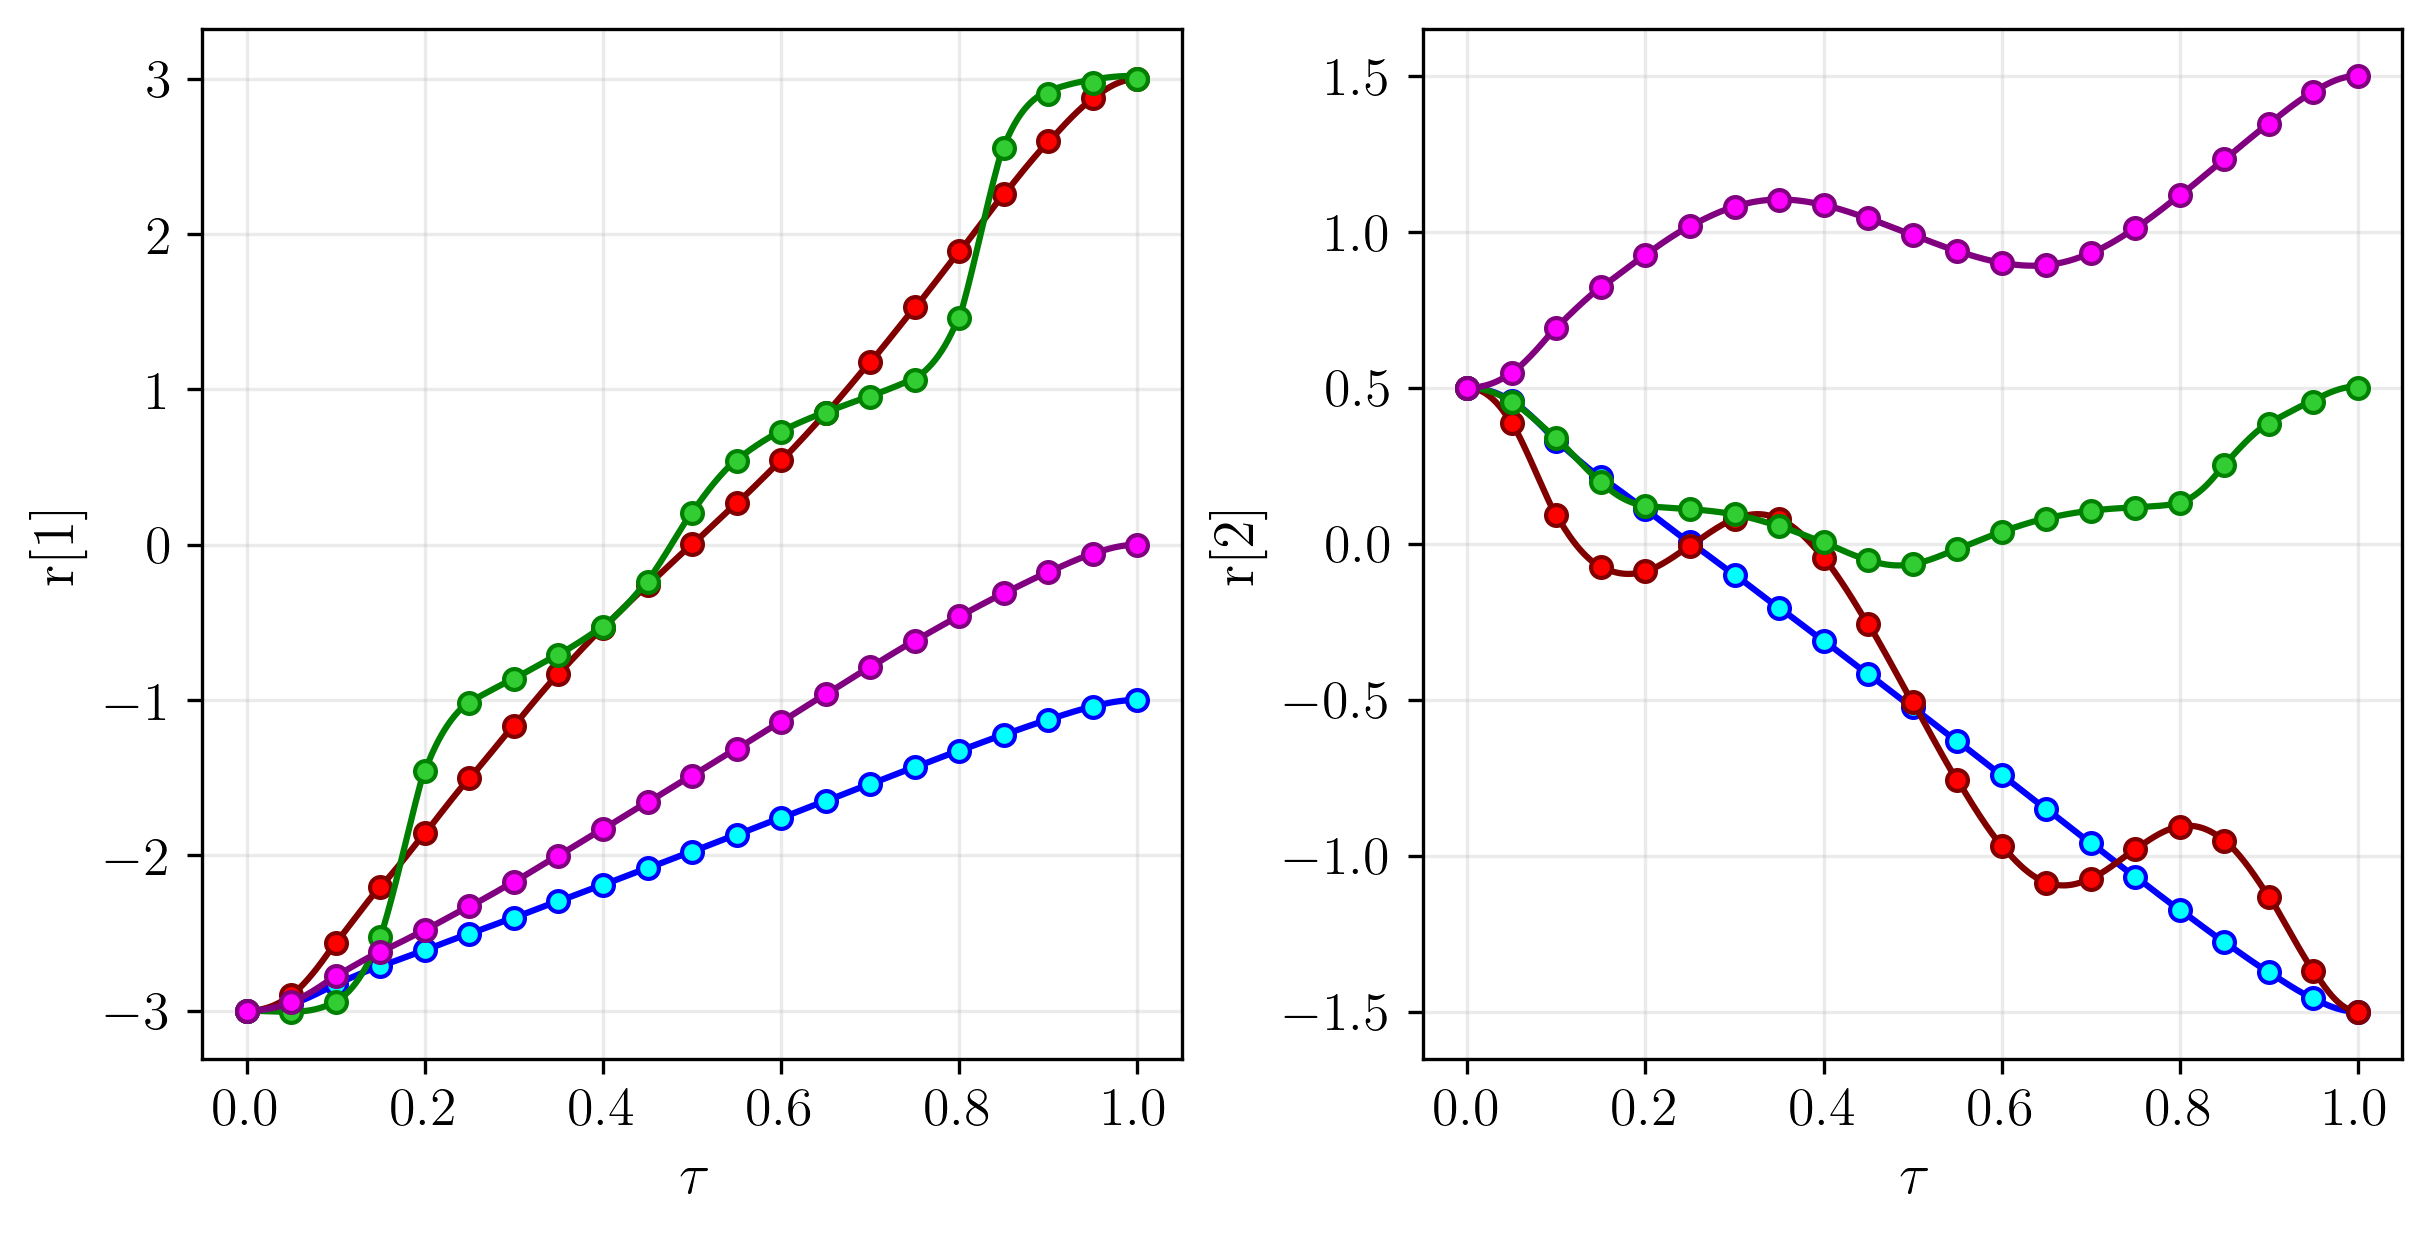

In [10]:
plot_3vec(
    params, 
    scp_solutions_proc, 
    scp_simulations_proc,
    "r";
    fname="plot_positions")

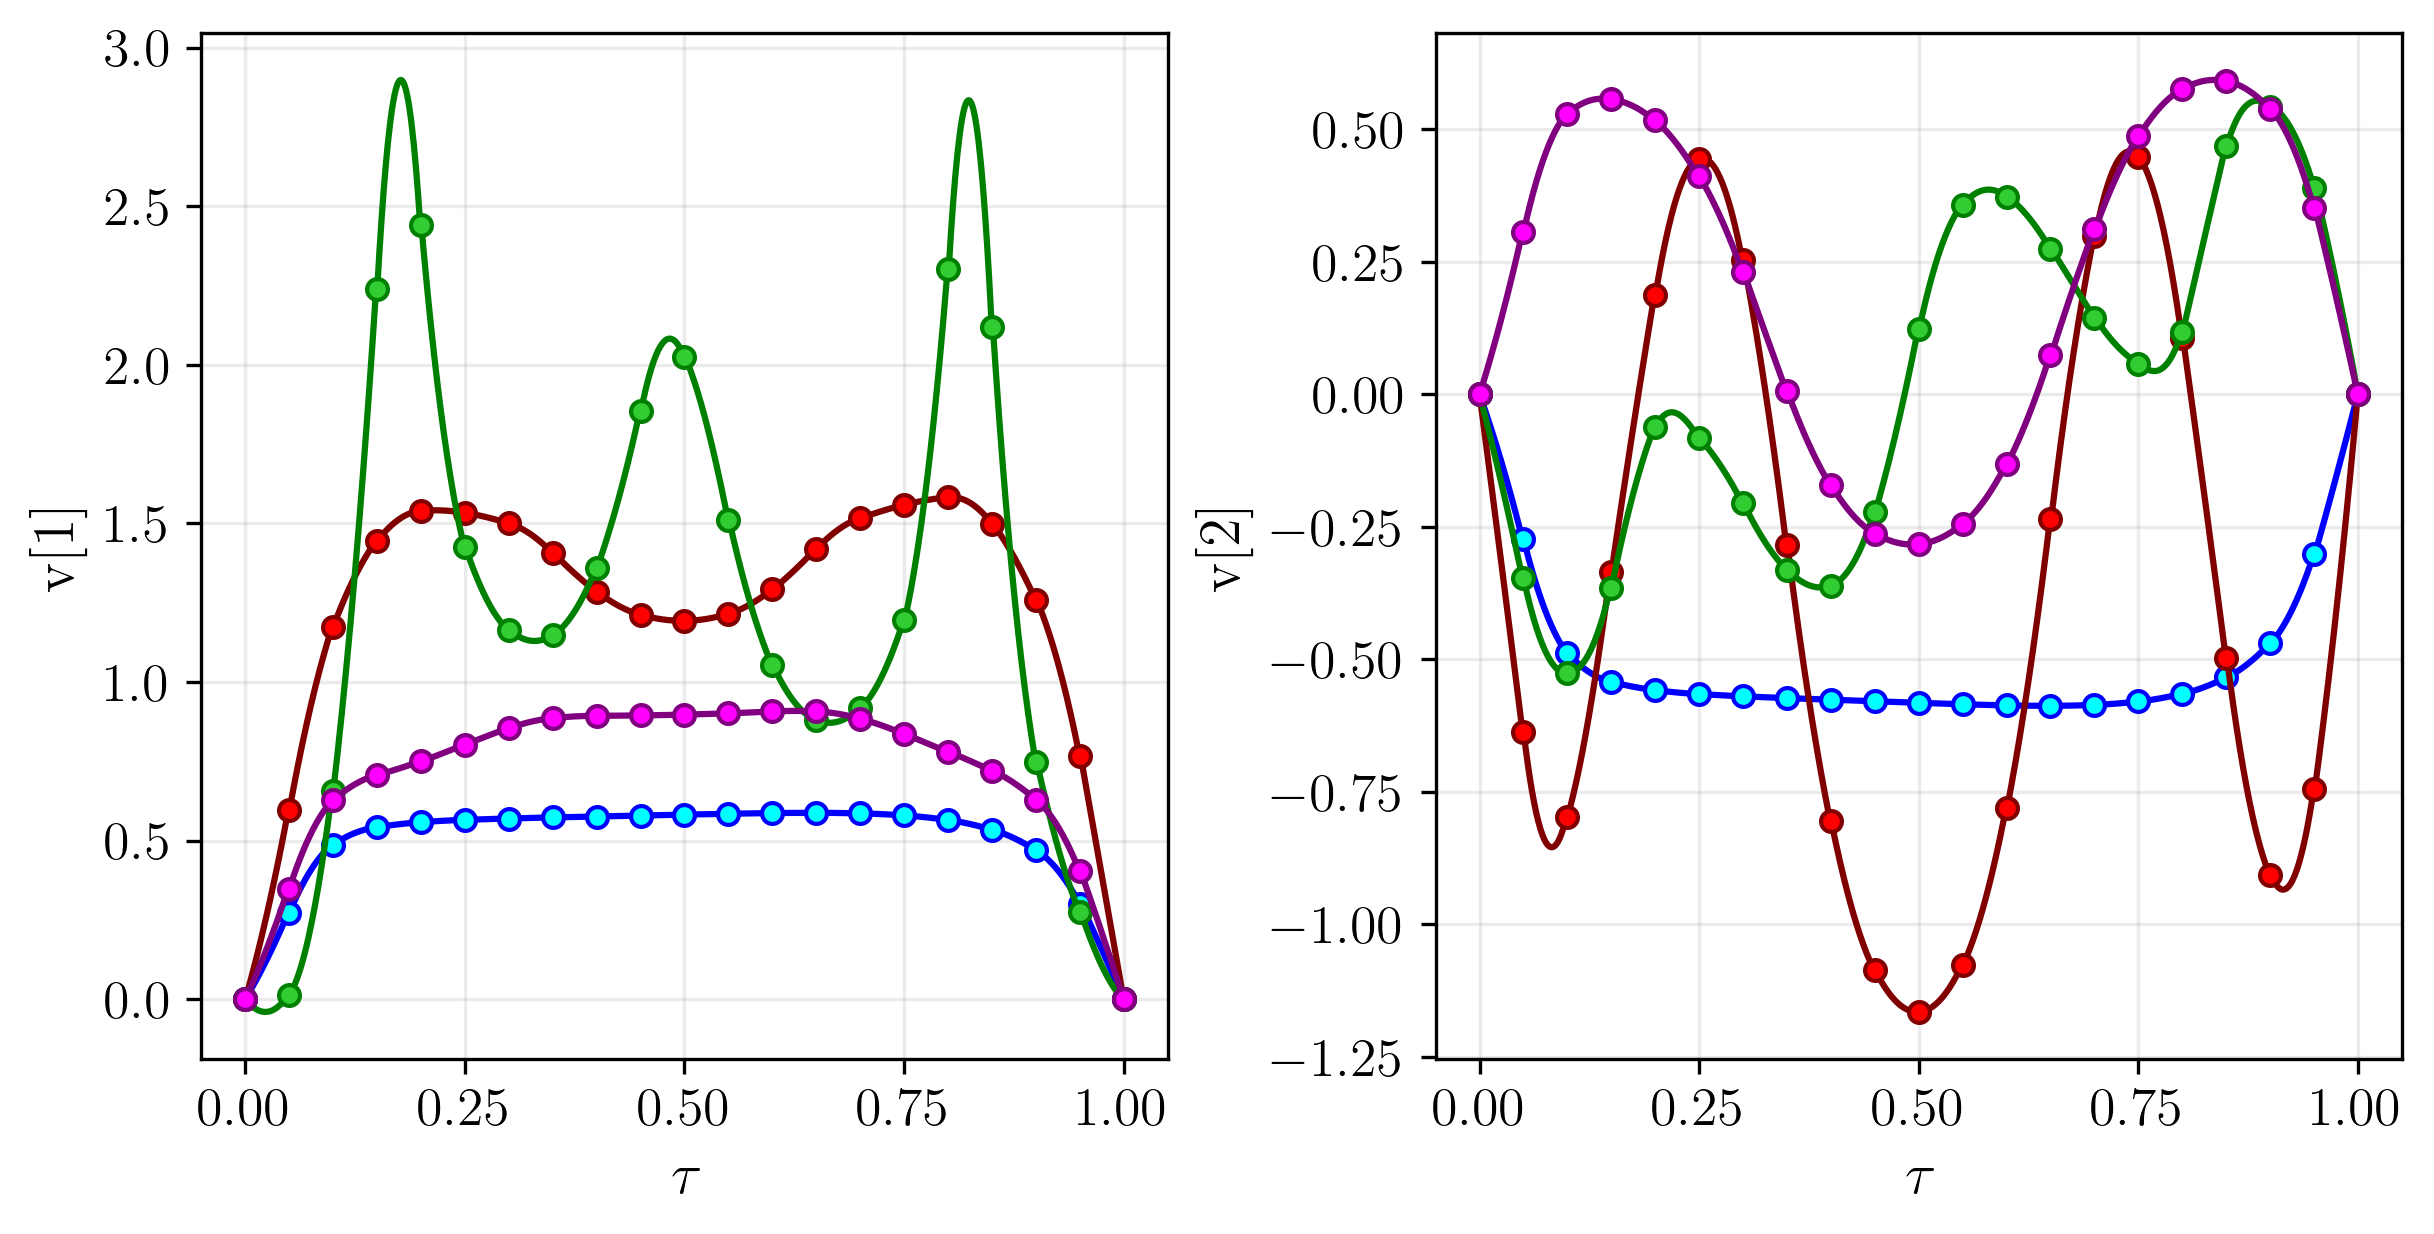

In [11]:
plot_3vec(
    params, 
    scp_solutions_proc, 
    scp_simulations_proc,
    "v";
    fname="temp")

#### DDTO Plots

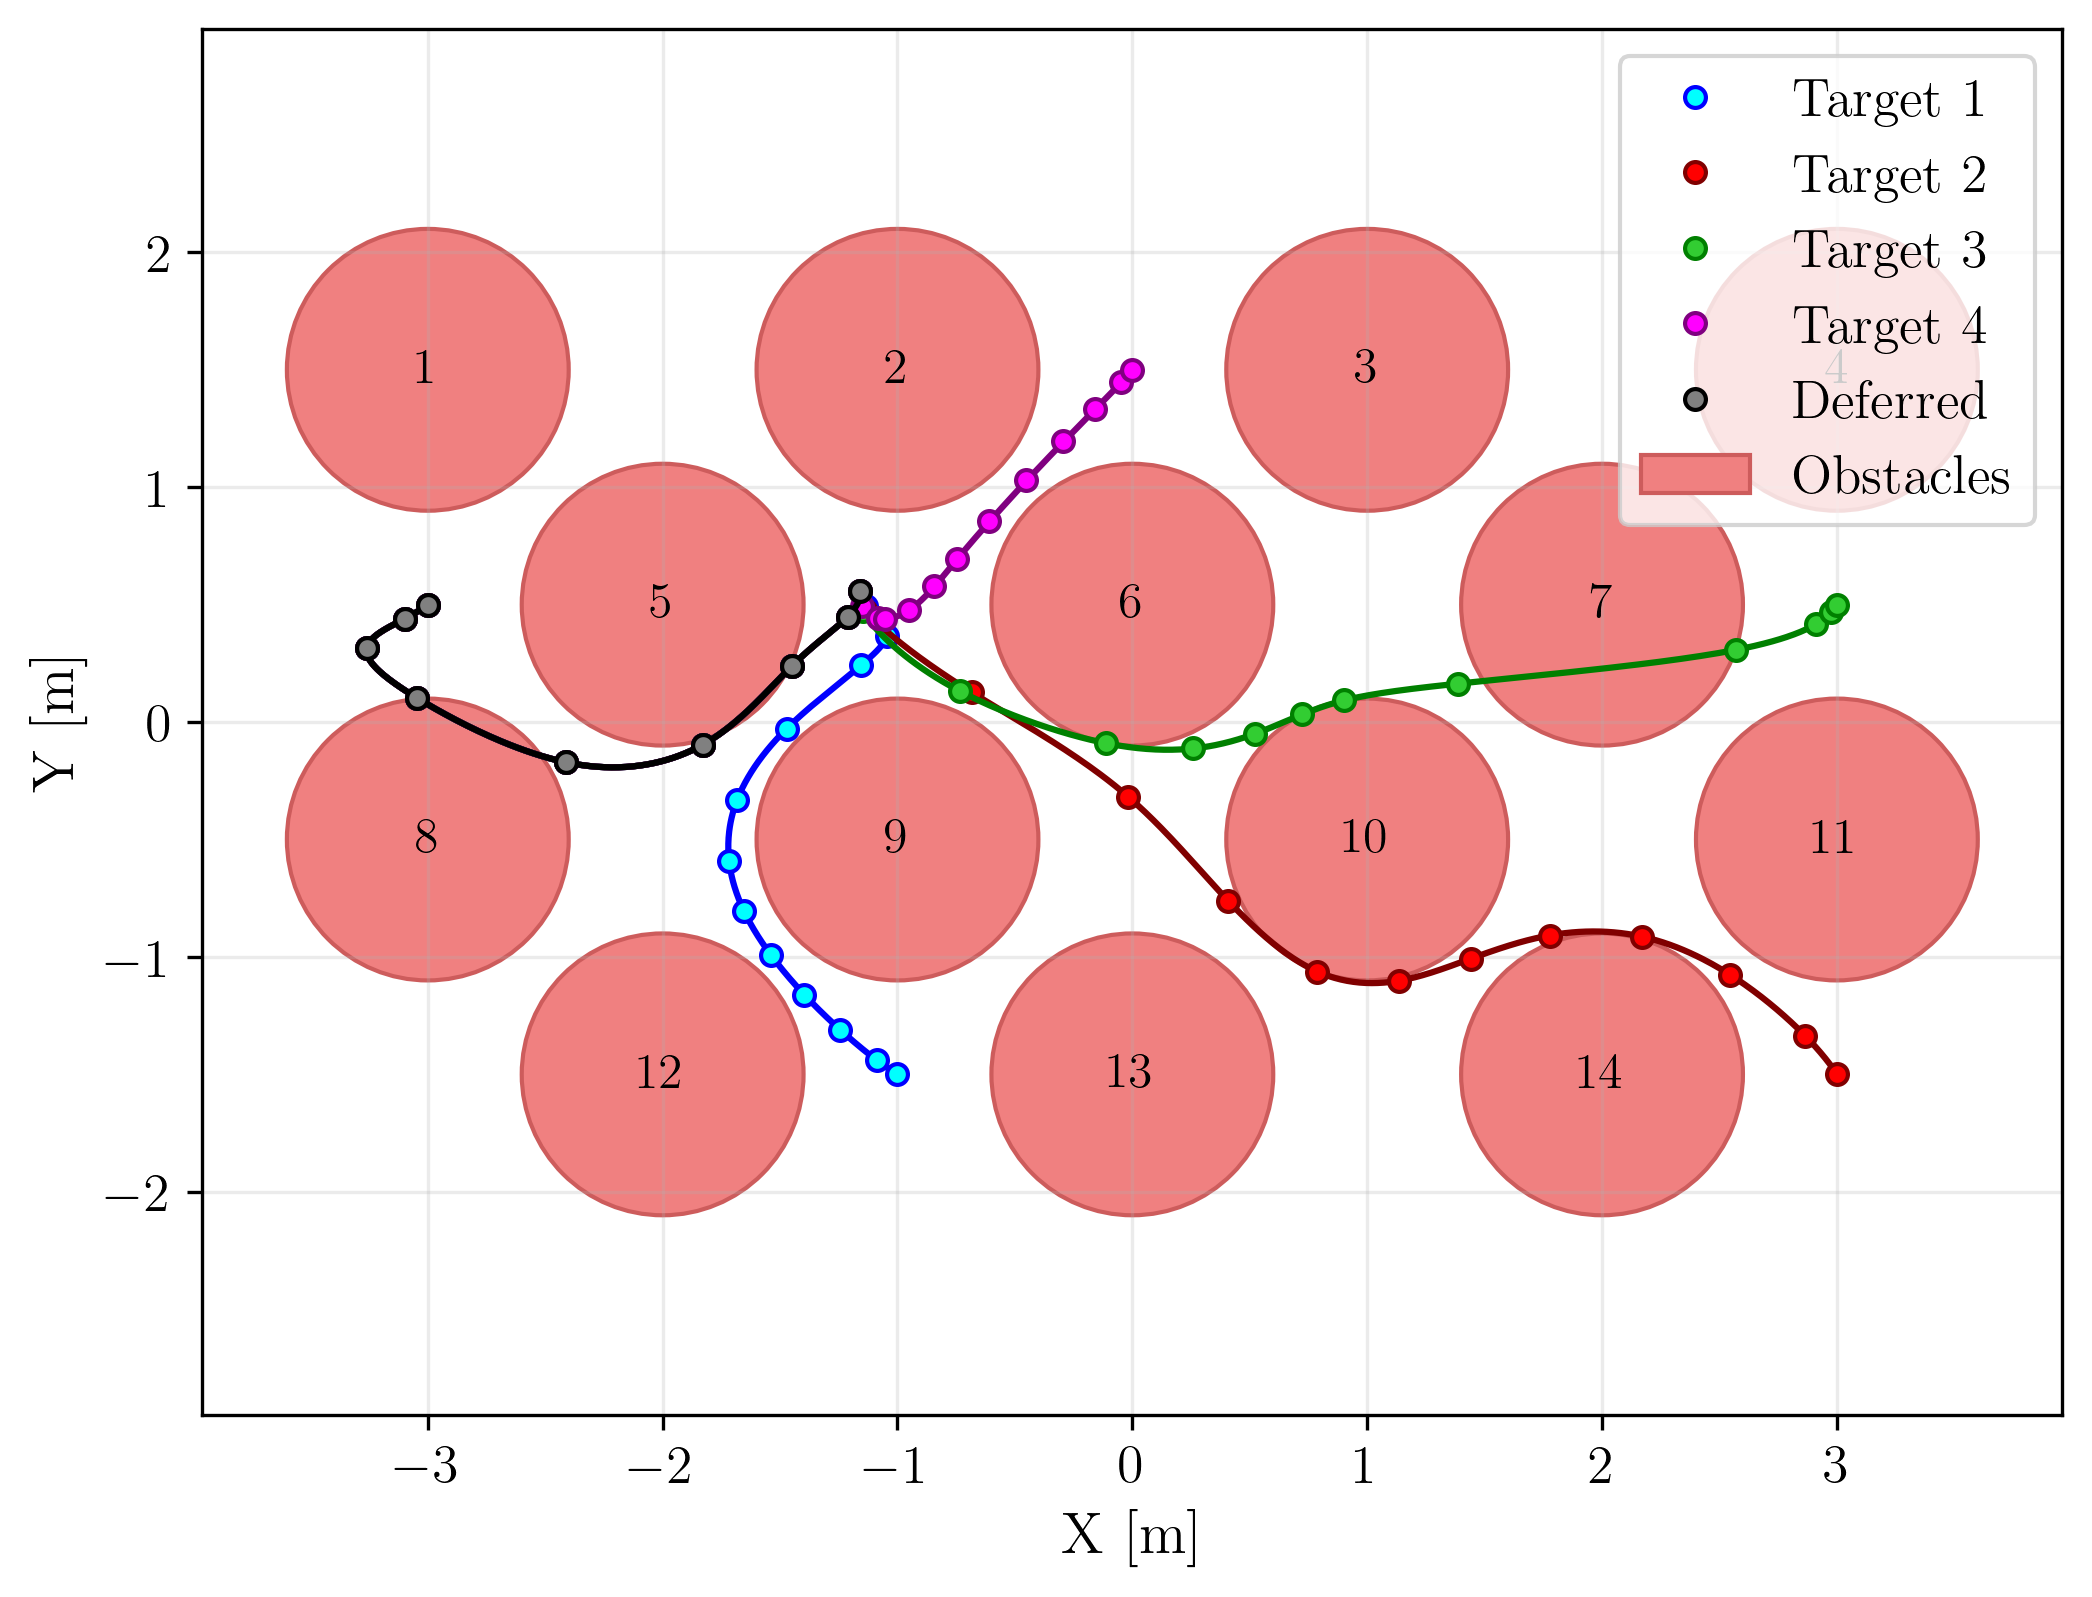

In [12]:
plot_parametric_trajectories(
    params, 
    ddtoscp_solutions_proc, 
    ddtoscp_simulations_proc;
    defer_solution=defer_solutions_proc,
    defer_simulation=defer_simulations_proc,
    display_obstacles=true,
    fname="ddtoscp_solutions")

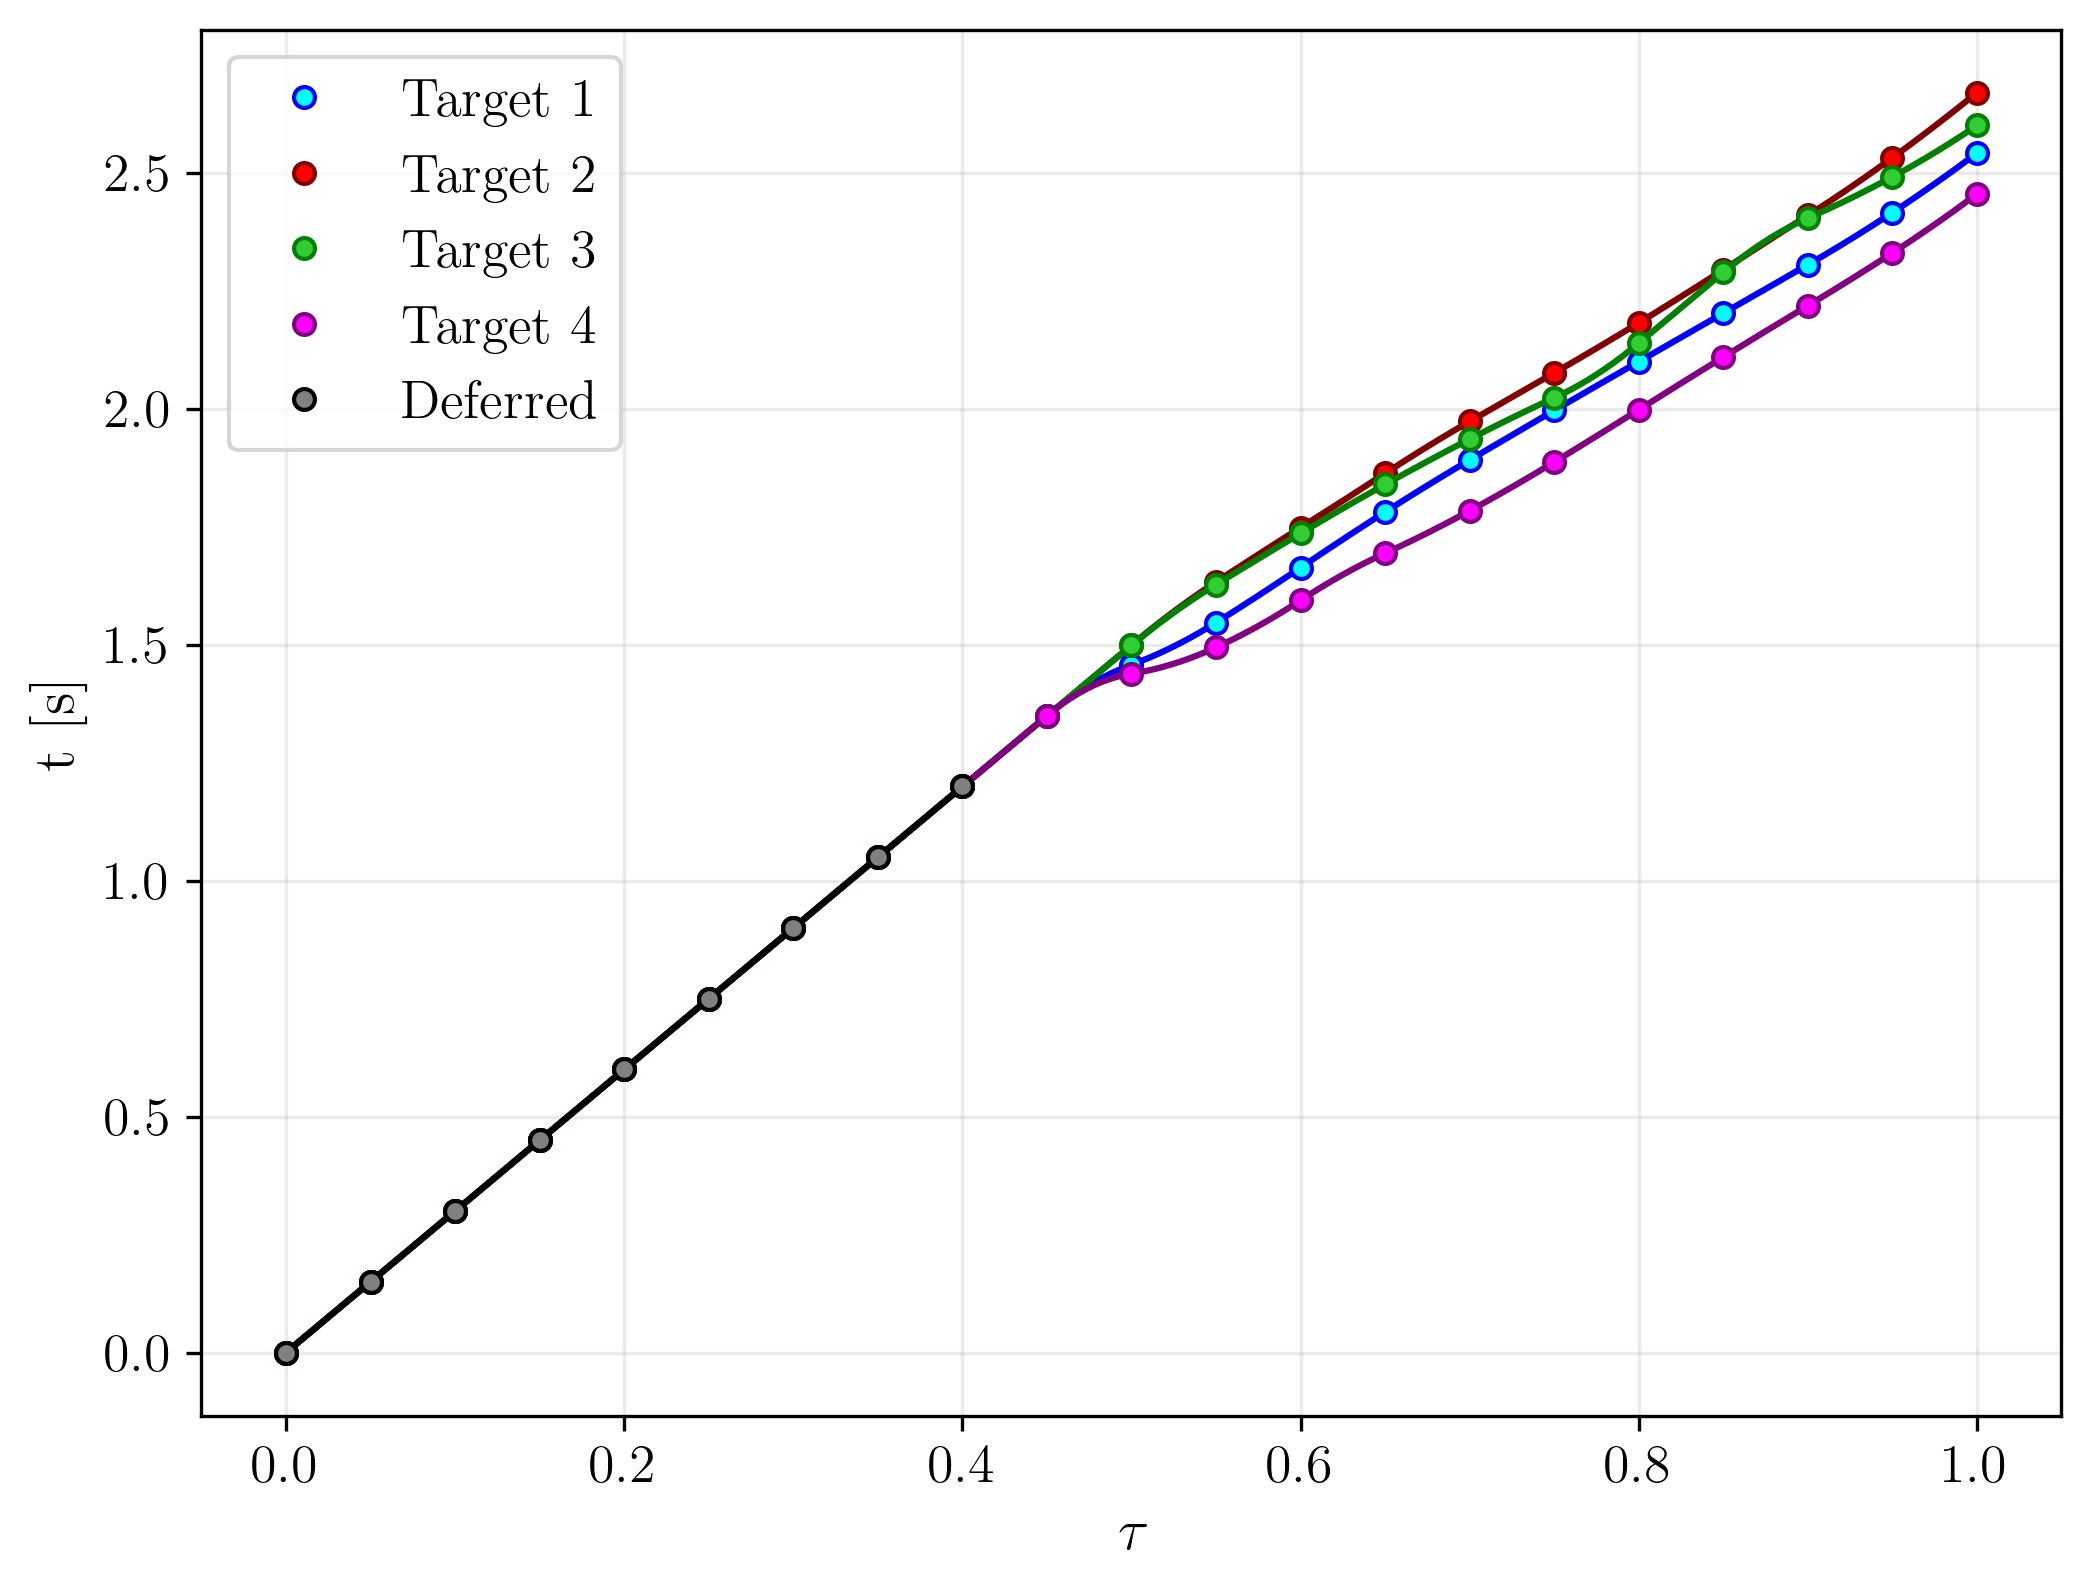

In [13]:
if params.free_final_time
    plot_time_dilation(
        params, 
        ddtoscp_solutions_proc, 
        ddtoscp_simulations_proc;
        defer_solution=defer_solutions_proc,
        defer_simulation=defer_simulations_proc,
        fname="plot_time_dilation")
end

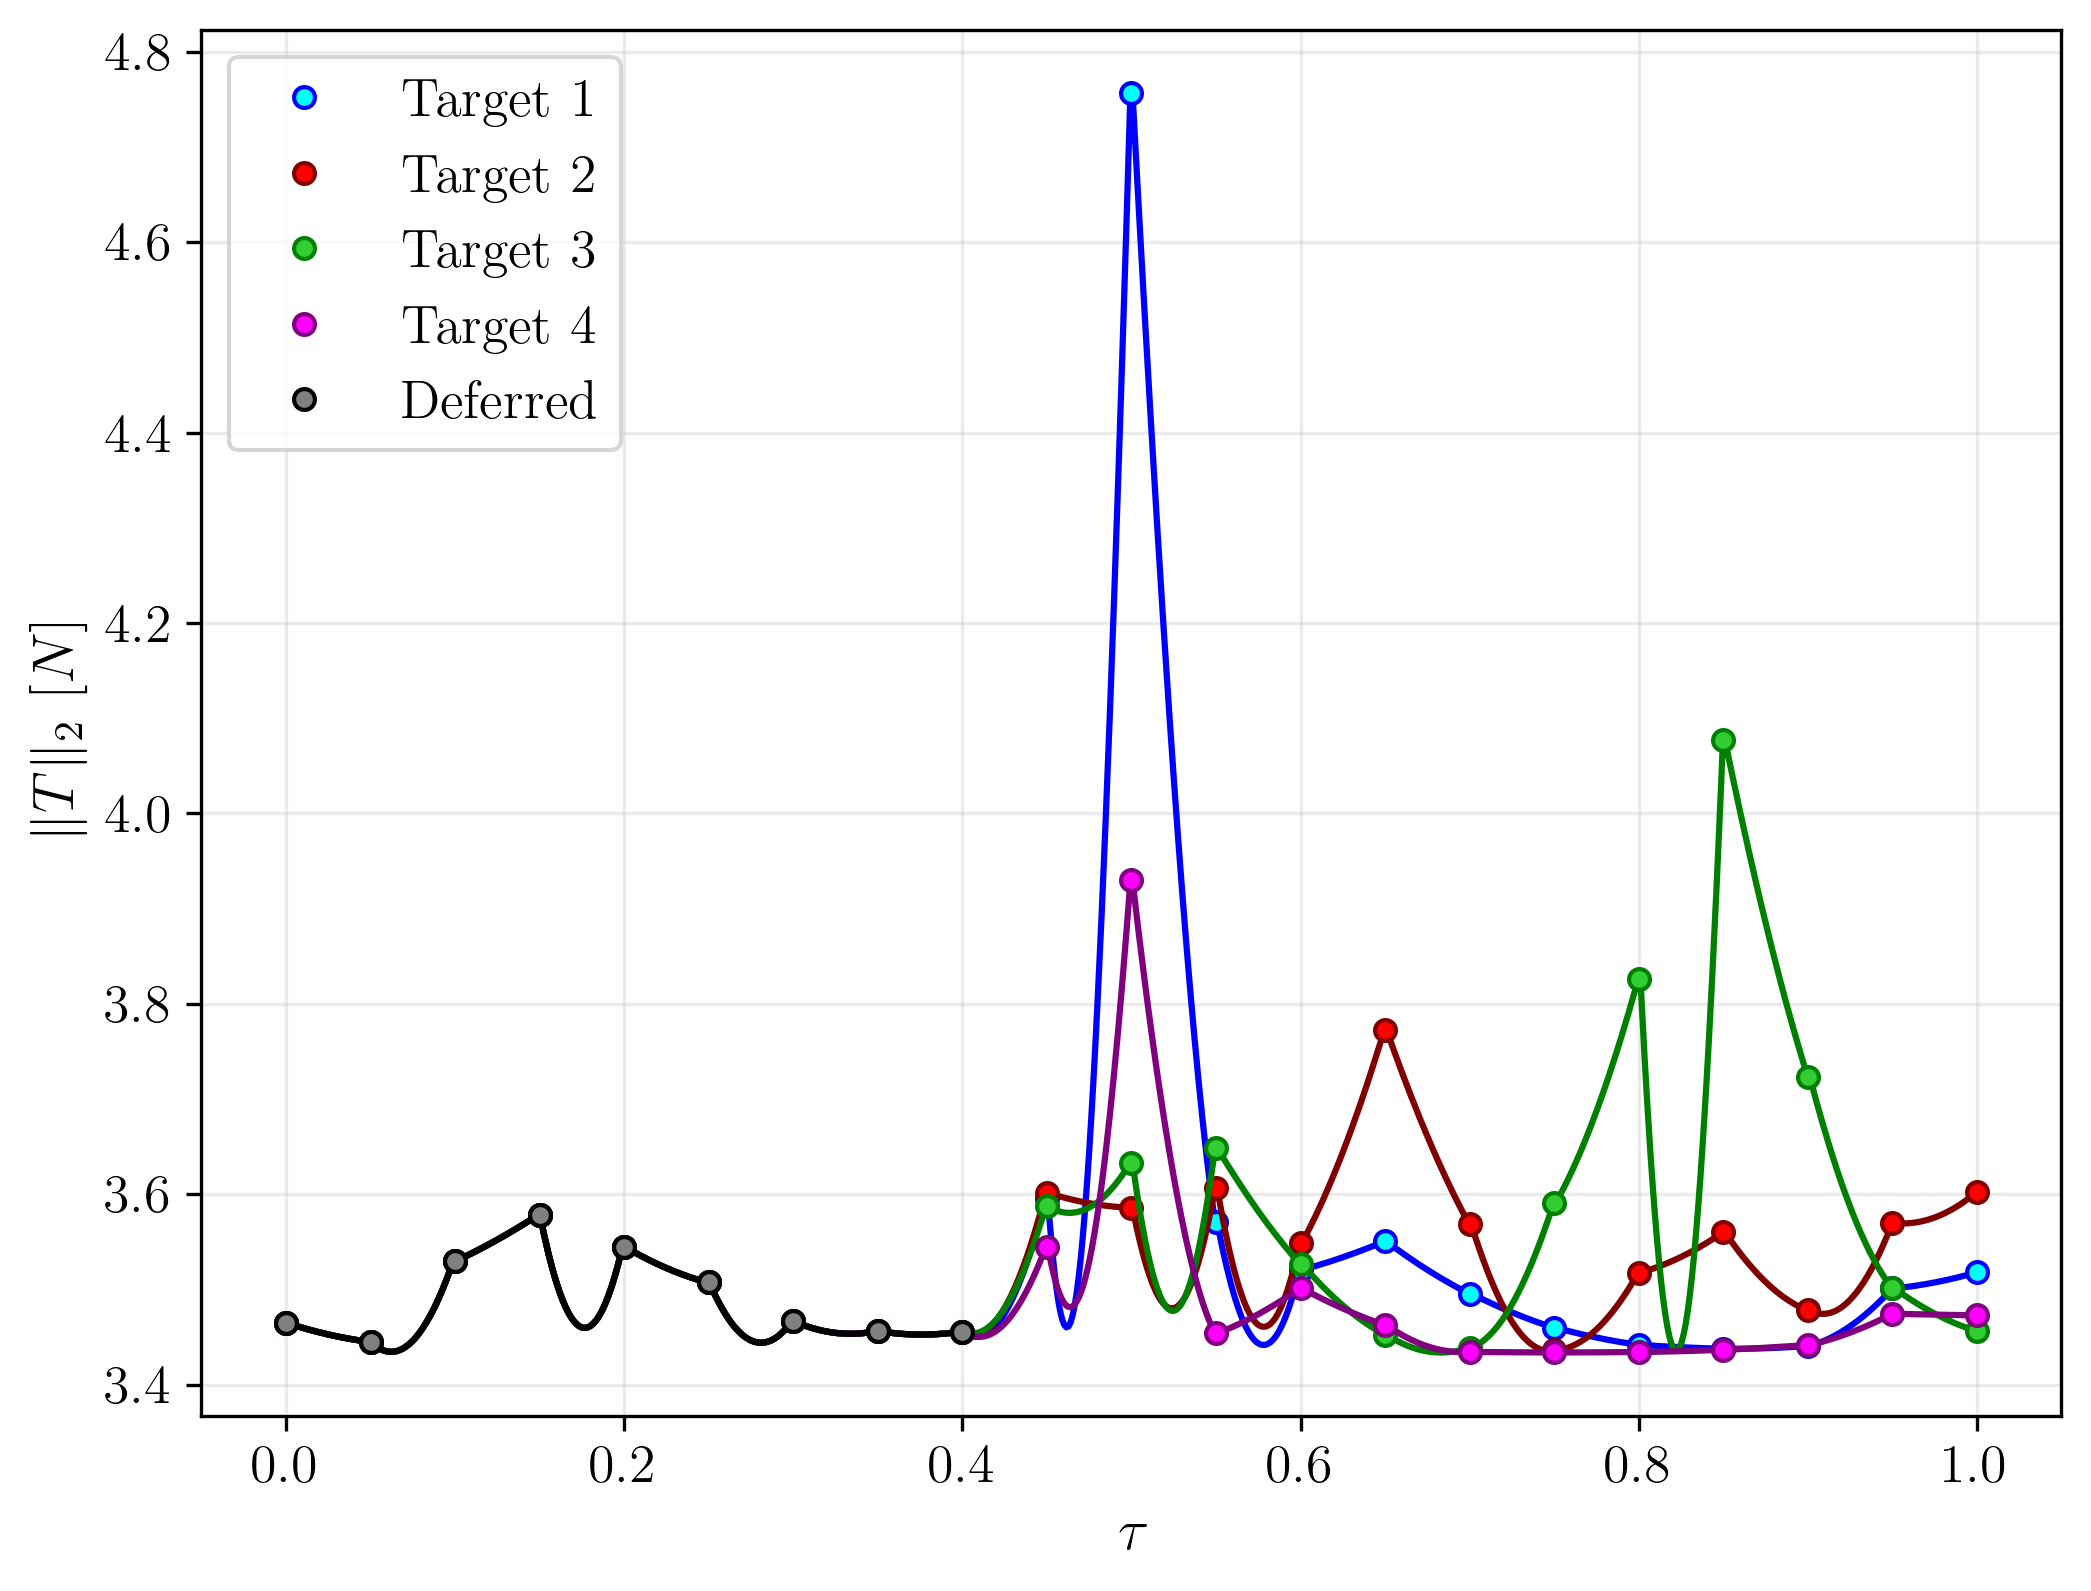

In [14]:
plot_thrust_magnitude(
    params, 
    ddtoscp_solutions_proc, 
    ddtoscp_simulations_proc;
    defer_solution=defer_solutions_proc,
    defer_simulation=defer_simulations_proc,
    fname="plot_thrust_magnitude")

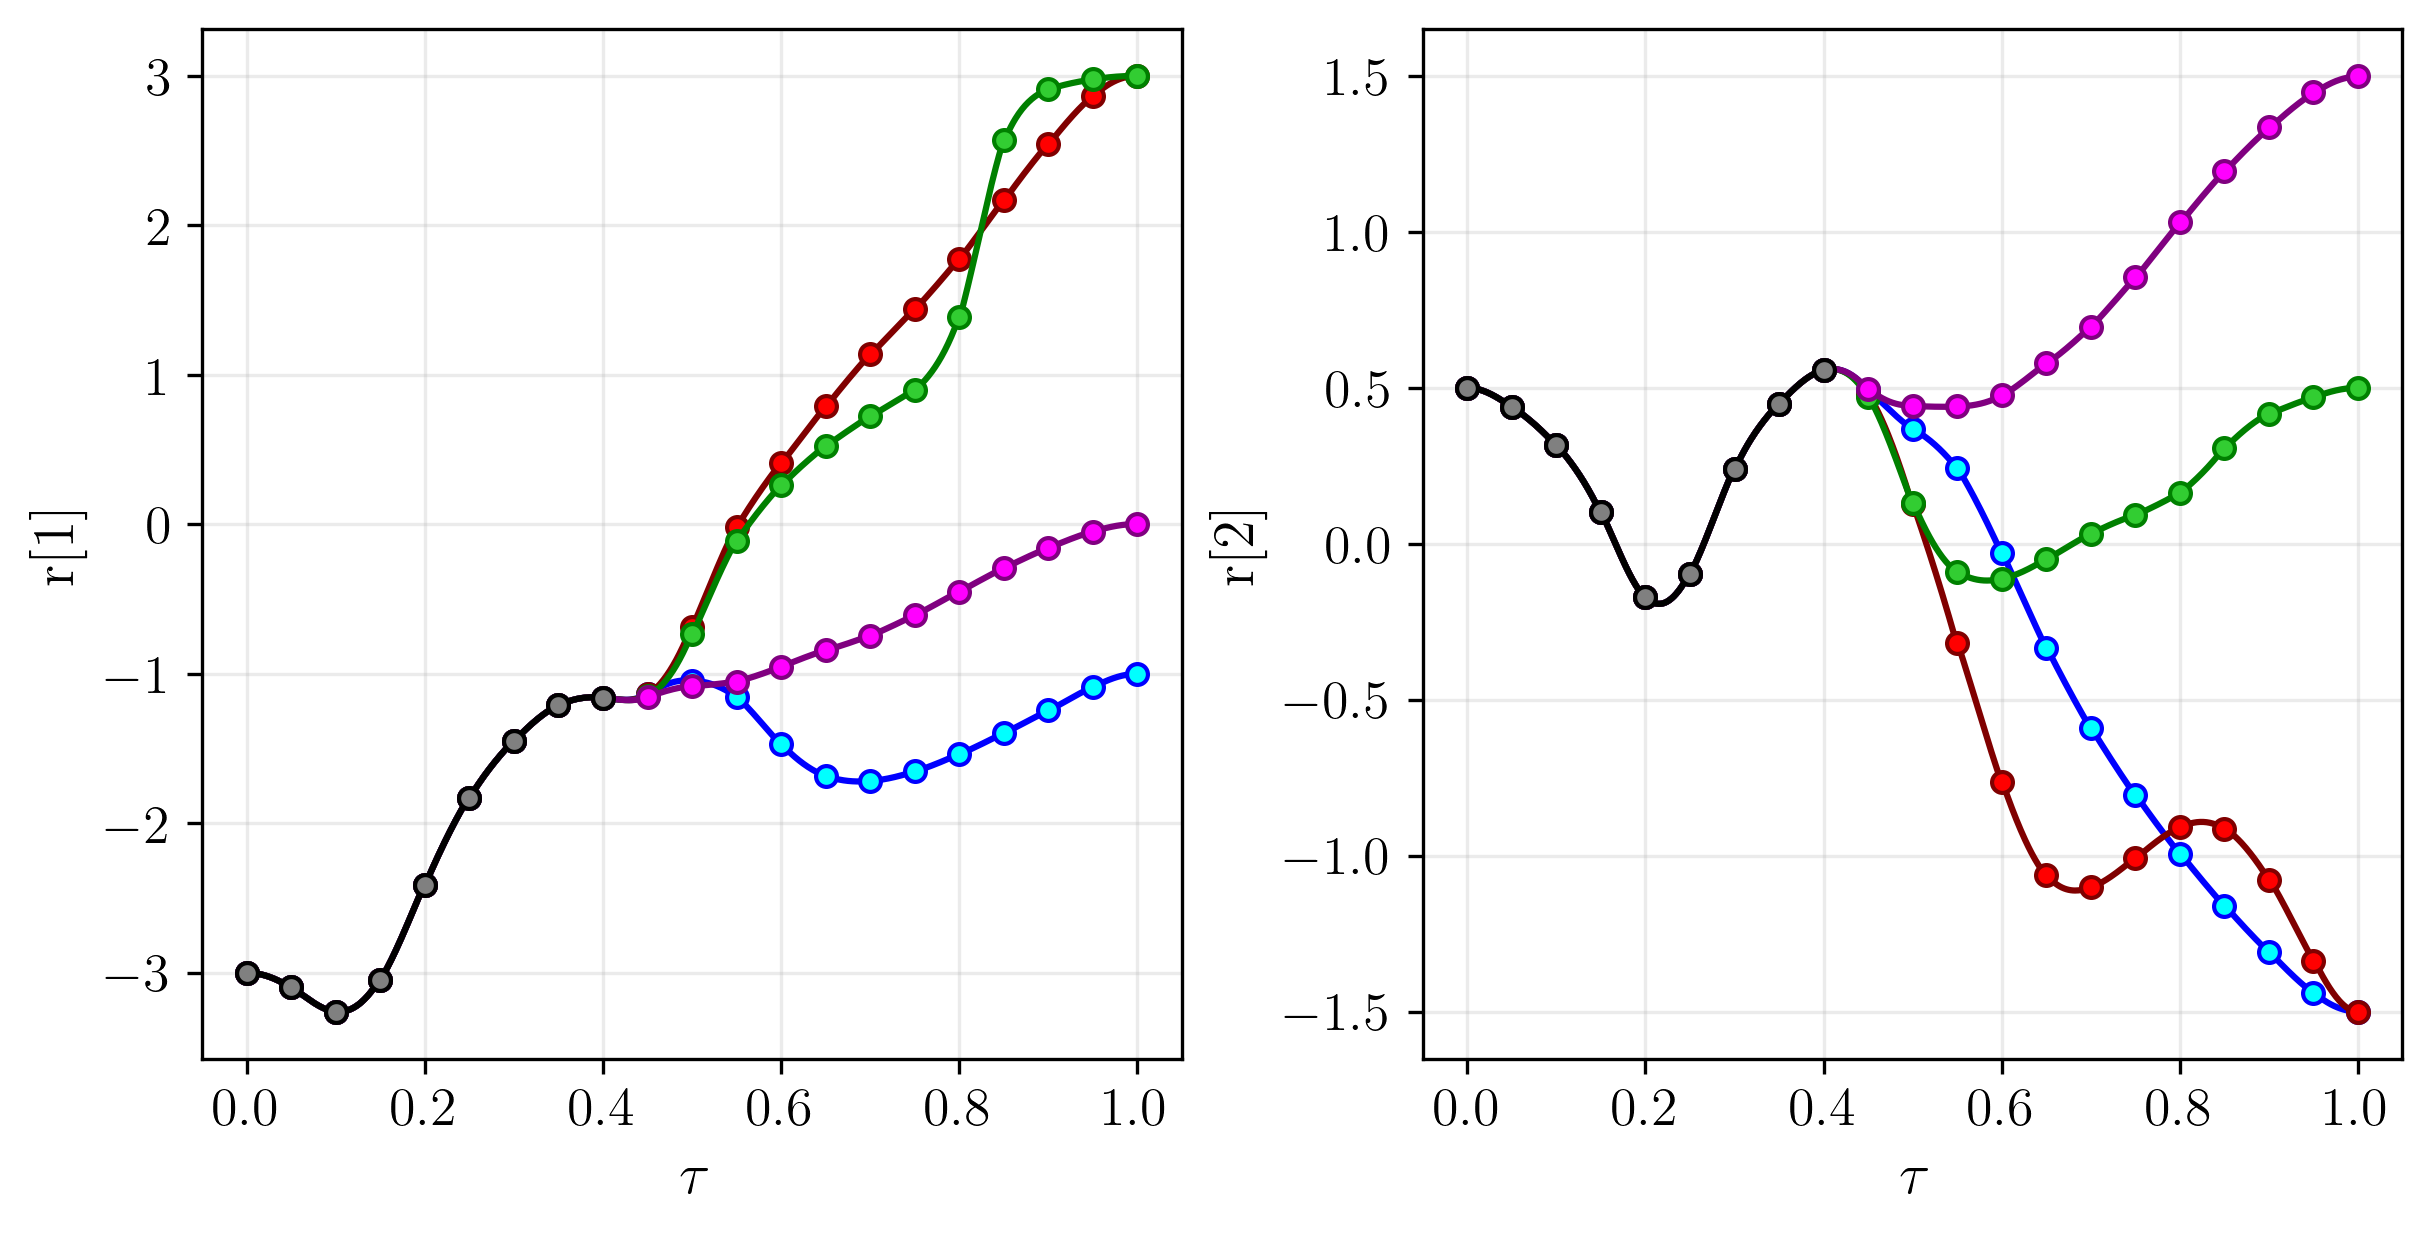

In [15]:
plot_3vec(
    params, 
    ddtoscp_solutions_proc, 
    ddtoscp_simulations_proc,
    "r";
    defer_solution=defer_solutions_proc,
    defer_simulation=defer_simulations_proc,
    fname="plot_positions")

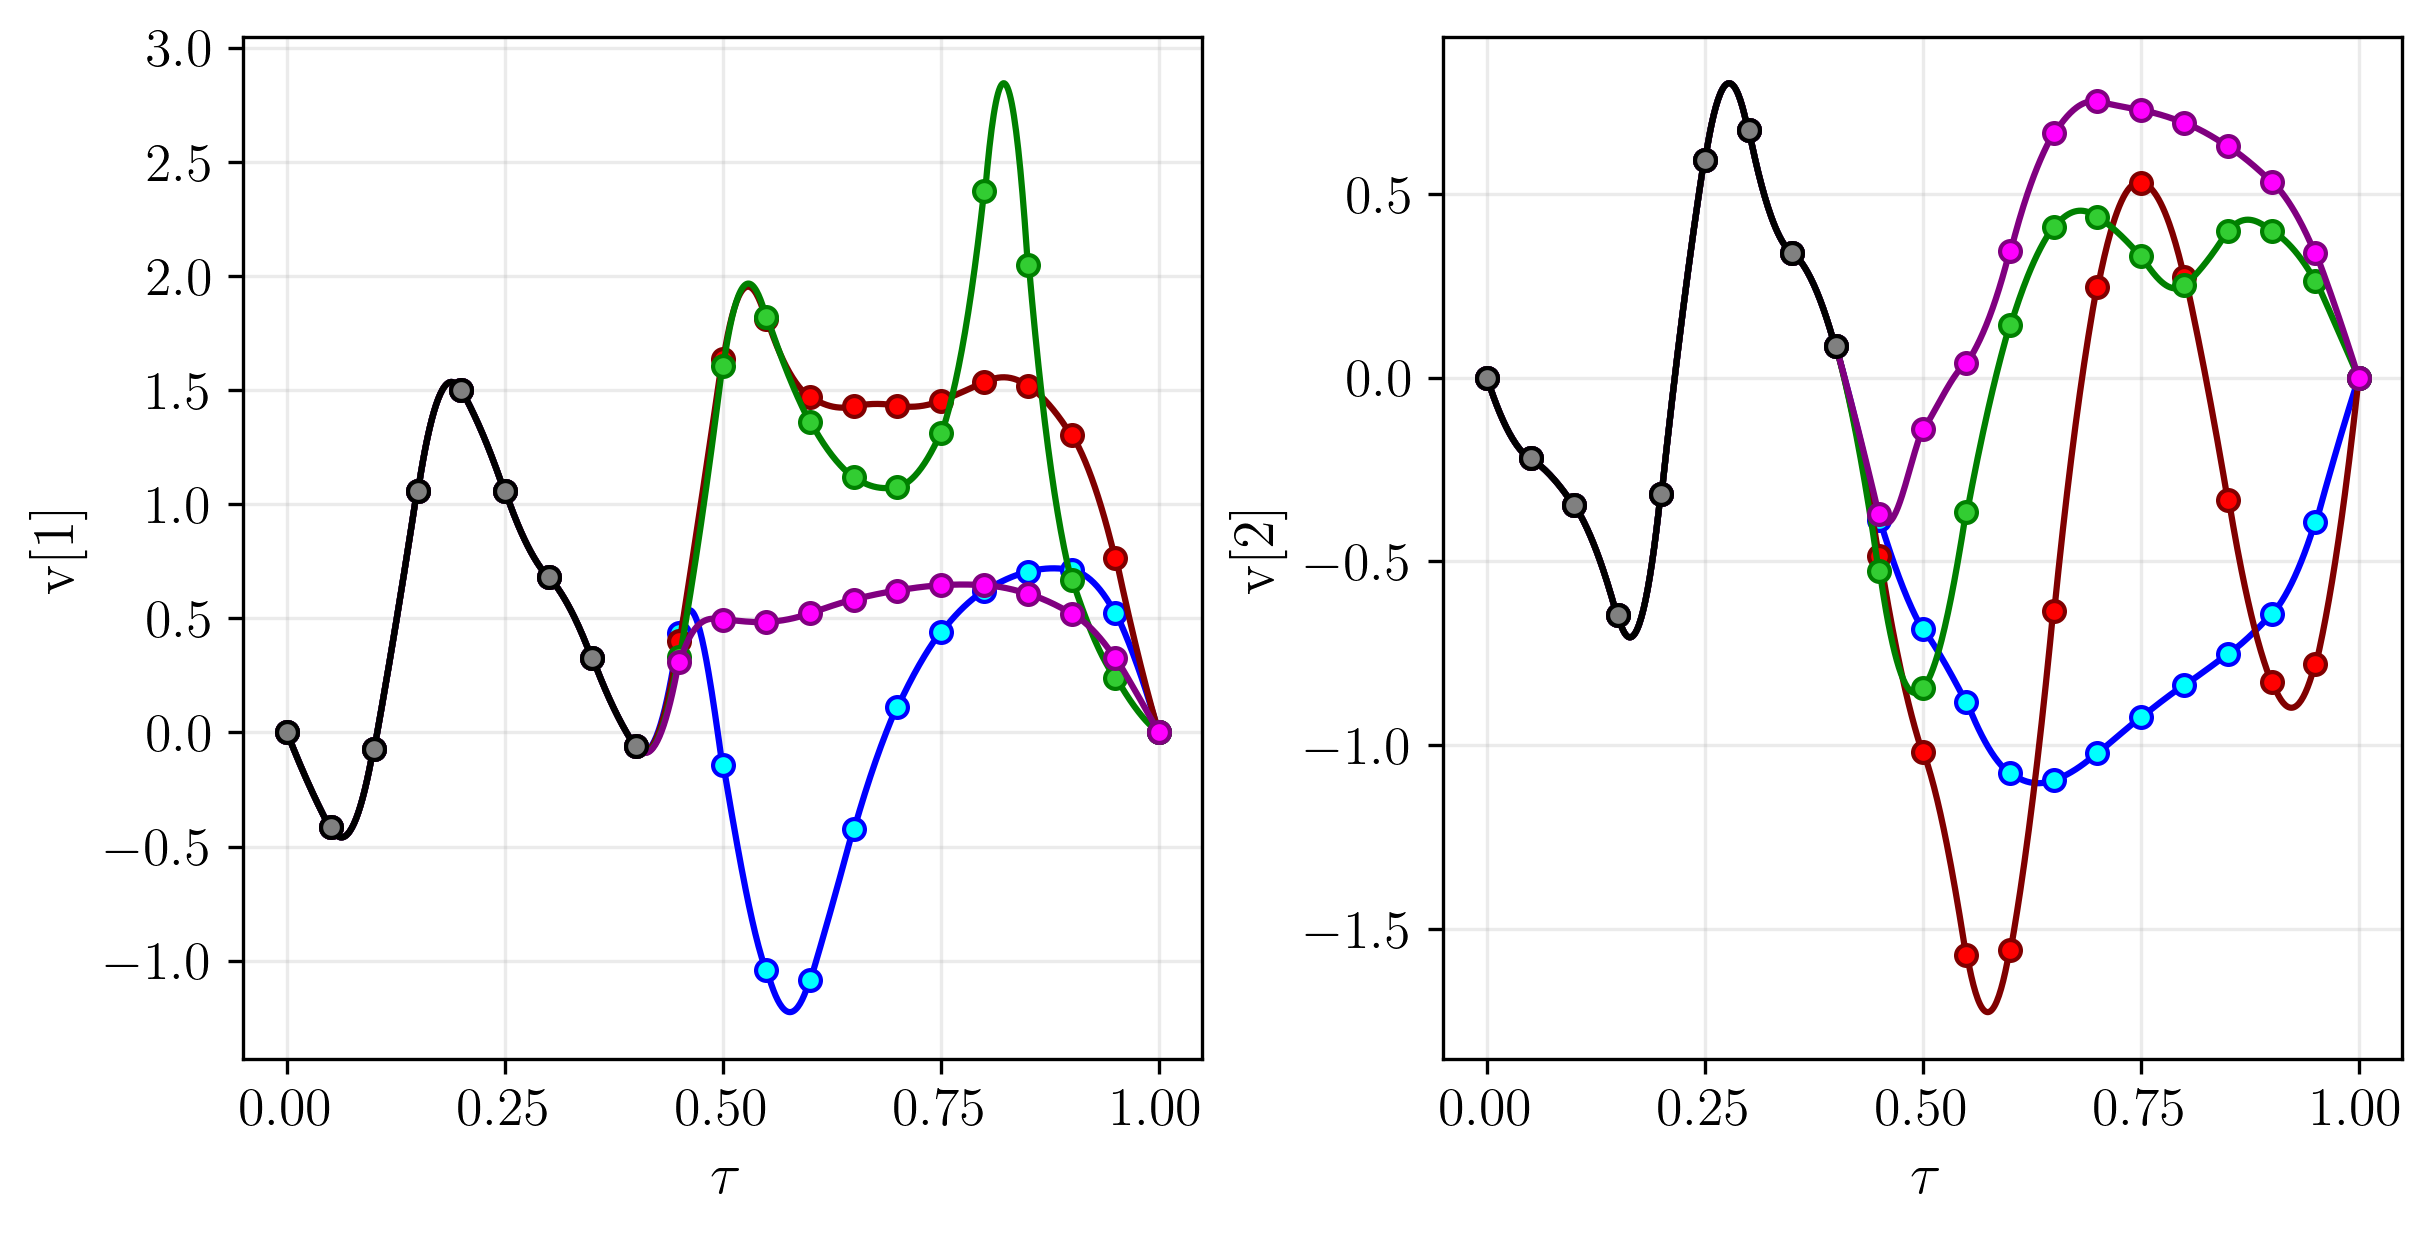

In [16]:
plot_3vec(
    params, 
    ddtoscp_solutions_proc, 
    ddtoscp_simulations_proc,
    "v";
    defer_solution=defer_solutions_proc,
    defer_simulation=defer_simulations_proc,
    fname="plot_positions")